# Feature Engineering and Modelling

---

1. Import packages
2. Load data
3. Modelling

---

## 1. Import packages

In [1]:
import warnings
from tabnanny import verbose

from IPython.core.pylabtools import figsize
from sklearn.metrics import precision_recall_curve
from xgboost.callback import EarlyStopping

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---
## 2. Load data

In [ ]:
df = pd.read_csv('../data/my_data_for_prediction.csv')
df = df.drop(columns = ['Unnamed: 0'])
df.info()
df.head()

---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [5]:
# Make a copy of our data_prepare
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 48)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 48)
(10954,)
(3652, 48)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm. 

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging. 

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [7]:
# Add model training in here!
model = RandomForestClassifier(n_estimators = 300, random_state = 42) # Add parameters to the model!
model.fit(X_train, y_train) # Complete this method call!

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [8]:
# Generate predictions here!
y_prediction = model.predict(X_test)

In [11]:
def valuate_performance(y_true, y_score):
    valuation_metrics = metrics.confusion_matrix(y_true, y_score)
    print(f"True negative(accurately predict the number of retained customer) {valuation_metrics[0, 0]}")
    print(f"False positive(wrongly predict the number of retained customer) {valuation_metrics[0, 1]}")
    print(f"False negative(wrongly predict the number of churned customer) {valuation_metrics[1, 0]}")
    print(f"True Positive(accurately predict the number of churned customer) {valuation_metrics[1, 1]}")
    print(f"accuracy score {metrics.accuracy_score(y_true, y_score)}")
    print(f"precision score {metrics.precision_score(y_true, y_score)}")
    print(f"recall score {metrics.recall_score(y_true, y_score)}")
        #proportion of positives that are correctly identified
    metrics.score

In [10]:
valuate_performance(y_test, y_prediction)

True negative(accurately predict the number of retained customer) 3298
False positive(wrongly predict the number of retained customer) 2
False negative(wrongly predict the number of churned customer) 332
True Positive(accurately predict the number of churned customer) 20
accuracy score 0.9085432639649507
precision score 0.9090909090909091
recall score 0.056818181818181816


In [11]:
model2 = RandomForestClassifier()
grid_search = GridSearchCV(estimator = model2,
                           # param_grid ={'n_estimators':[20,50,100,200],
                           #              'max_features': [5,7,9,12],
                           #             'class_weight': [{0:1, 1:10}, {0:1, 1:12}, {0:1, 1:15}, 'balanced']},
                            param_grid ={'n_estimators':[50],
                                        'max_features': [12],
                                       'class_weight': ['balanced']},
                           scoring='recall',
                           random_state = 42,
                           cv = 5)
grid_search.fit(X_train,y_train)
grid_search.best_params_

{'class_weight': 'balanced', 'max_features': 12, 'n_estimators': 50}

In [12]:
# display(grid_search.cv_results_)
model2 = grid_search.best_estimator_

In [13]:
y_prediction2 = model2.predict(X_test)
valuate_performance(y_test, y_prediction2)

True negative(accurately predict the number of retained customer) 3294
False positive(wrongly predict the number of retained customer) 6
False negative(wrongly predict the number of churned customer) 330
True Positive(accurately predict the number of churned customer) 22
accuracy score 0.9079956188389924
precision score 0.7857142857142857
recall score 0.0625


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, stratify = y,train_size = 0.8, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, stratify = y_temp, train_size = 0.5, random_state = 42)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(11684, 48)
(1461, 48)
(1461, 48)


In [23]:
model3 = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
model3.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
p_val = model3.predict_proba(X_val)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val, p_val)

target_recall = 0.65
idx = np.where(recall >= target_recall) [0]
display(thresholds[idx])

proper_thresholds = thresholds[idx[-1]]
proper_thresholds

array([0.        , 0.01      , 0.01822919, 0.02      , 0.03      ,
       0.04      , 0.05      , 0.06      , 0.07      , 0.08      ])

np.float64(0.08)

Text(0, 0.5, 'Recall')

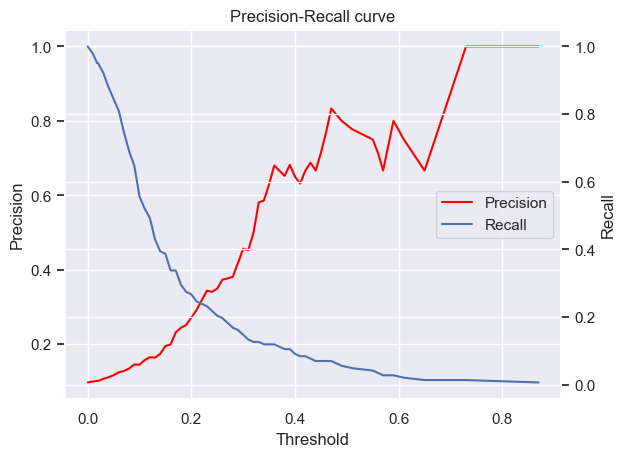

In [52]:
plt.plot(figsize = (10,6))
ax1 = plt.gca()
ax2 = plt.twinx()
line1 = ax1.plot(thresholds, precision[:-1], label = 'Precision', color = 'red')
line2 = ax2.plot(thresholds, recall[:-1], label = 'Recall')

line = line1 + line2
line_label = [l.get_label() for l in line]
ax1.legend(handles = line, labels = line_label, loc = 'center right')
ax1.set_title('Precision-Recall curve')

ax1.set_xlabel('Threshold')
ax1.set_ylabel('Precision')
ax2.set_ylabel('Recall')

In [53]:
y_prediction3 = (model3.predict_proba(X_test)[:,1] >= proper_thresholds).astype('int64')
valuate_performance(y_test, y_prediction3)

True negative(accurately predict the number of retained customer) 670
False positive(wrongly predict the number of retained customer) 649
False negative(wrongly predict the number of churned customer) 40
True Positive(accurately predict the number of churned customer) 102
accuracy score 0.5284052019164955
precision score 0.13581890812250333
recall score 0.7183098591549296


In [27]:
beta = 2
f_beta = (1 + beta ** 2) * precision * recall / (beta ** 2 * precision + recall)
display(f_beta)
idx = np.argmax(f_beta)
proper_thresholds = thresholds[idx]
proper_thresholds

array([0.34992607, 0.35459184, 0.35507628, 0.35526316, 0.36490251,
       0.36960378, 0.37546934, 0.38513061, 0.37992832, 0.37837838,
       0.38333333, 0.3545781 , 0.35611165, 0.35282258, 0.32446809,
       0.31460674, 0.32352941, 0.29666255, 0.30967742, 0.28378378,
       0.26970954, 0.26836158, 0.25436047, 0.25185185, 0.24849398,
       0.23520486, 0.22273425, 0.21772939, 0.20408163, 0.19017433,
       0.18459069, 0.17100977, 0.1557377 , 0.14900662, 0.15025042,
       0.14237856, 0.14285714, 0.14333895, 0.12690355, 0.12711864,
       0.11054422, 0.10221465, 0.10238908, 0.09417808, 0.08576329,
       0.08591065, 0.08605852, 0.0862069 , 0.06920415, 0.06065858,
       0.05208333, 0.04347826, 0.03484321, 0.03490401, 0.02622378,
       0.01751313, 0.01754386, 0.00878735, 0.        ])

np.float64(0.06)

In [28]:
y_prediction4 = (model3.predict_proba(X_test)[:,1] >= proper_thresholds).astype('int64')
valuate_performance(y_test, y_prediction4)

True negative(accurately predict the number of retained customer) 490
False positive(wrongly predict the number of retained customer) 829
False negative(wrongly predict the number of churned customer) 28
True Positive(accurately predict the number of churned customer) 114
accuracy score 0.4134154688569473
precision score 0.12089077412513255
recall score 0.8028169014084507


In [8]:
CALLBACKS = [
    EarlyStopping(
        rounds = 100,
        save_best = True,
        maximize = True
    )
]

xgb = XGBClassifier(n_estimators = 2000,
                    learning_rate = 0.05,
                    max_depth = 5,
                    eval_metric = 'aucpr',
                    callbacks = CALLBACKS,
                    min_child_weight = 5,
                    objective='binary:logistic',
                    subsample = 0.8,
                    scale_pos_weight= 9,
                    random_state = 42)

grid_search = GridSearchCV(estimator = xgb,
                           param_grid = {
                               "learning_rate" : [0.3, 0.5, 0.7],
                               "subsample": [0.8, 0.7],
                               "colsample_bytree": [0.8, 0.7],
                               "max_depth": [3, 4, 5]
                           },
                           scoring = "average_precision")
grid_search.fit(X_train,y_train,
                eval_set = [(X_val, y_val)],
                verbose = False)
xgb = grid_search.best_estimator_
# xgb.fit(X_train, y_train,w
#         verbose = False)

In [9]:
xgb

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",[<xgboost.call...00295A3894910>]
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.dat

In [17]:
p_val = xgb.predict_proba(X_val)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val, p_val)

beta = 2
f_beta = (1 + beta ** 2) * precision * recall / (beta ** 2 * precision + recall)
display(f_beta)
idx = np.argmax(f_beta)
proper_thresholds = thresholds[idx]
proper_thresholds

y_prediction5 = (xgb.predict_proba(X_test)[:,1] >= proper_thresholds).astype('int64')
valuate_performance(y_test, y_prediction5)

array([0.34992607, 0.35009862, 0.35027134, ..., 0.01754386, 0.00878735,
       0.        ], shape=(1462,))

True negative(accurately predict the number of retained customer) 802
False positive(wrongly predict the number of retained customer) 517
False negative(wrongly predict the number of churned customer) 53
True Positive(accurately predict the number of churned customer) 89
accuracy score 0.6098562628336756
precision score 0.14686468646864687
recall score 0.6267605633802817
